# Personal project for trying out Euler-Maruyama

Euler-Maruyama is a method to approximate a numerical solution to a given SDE (stochastic differential equation).

In [2]:
# preliminaries
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
#rng setup
rng= np.random.default_rng(0)

# basic setup
T= 1
time_interval = [0,T]
subint_N = 1000
iter = 10
delta_T = (time_interval[1]-time_interval[0])/subint_N

# Asssume that the interval starts from zero. 
time_subintervals = np.linspace(0, T, num=subint_N, endpoint=True)

# A very preliminary step: visualise Brownian motion
This is, of course, easy to do as we have that
$W_t\sim \mathcal{N}(0,t)$, in particular for every increment, $W_t-W_s\sim \mathcal{N}(0,t-s)$, where $t\ge s$. We also have the following trick for reusing the normal generator: $z=\sqrt{t-s}\epsilon$, where $\varepsilon\sim \mathcal{N}(0,1)$, to obtain $W_t$. 

In [18]:
normal = rng.normal(0,1,(iter,subint_N))

# initialise the array
paths= np.zeros((iter,subint_N))

for i in range(subint_N-1):
    real_idx = i+1
    paths[:,real_idx]=paths[:,real_idx-1]+np.sqrt(delta_T)*normal[:,i]

Plotting the results (very barebones plot): 

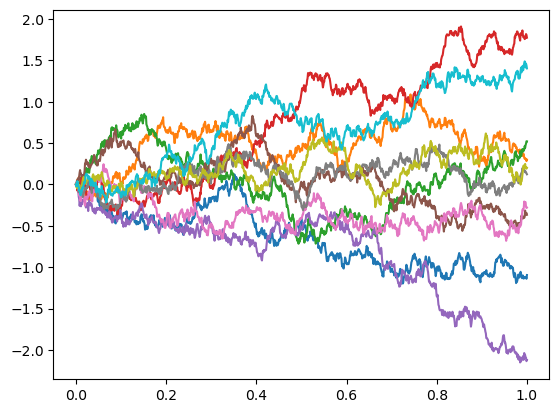

In [20]:
for i in range(iter):
    plt.plot(time_subintervals, paths[i,:])

# Something more advanced: Brownian bridge

We can use the Brownian motion from above to obtain a Brownian bridge, as we have:
$B(t)=W(t)-t/T[W(T)]$

In [21]:
# Pick one realisation of BM for now.
brown_bridge_paths = np.zeros((iter,subint_N))

for i in range(subint_N-1):
    brown_bridge_paths[:,i] = paths[:,i]-(time_subintervals[i]/T)*paths[:,subint_N-1]


Similarly, we make a simple plot:

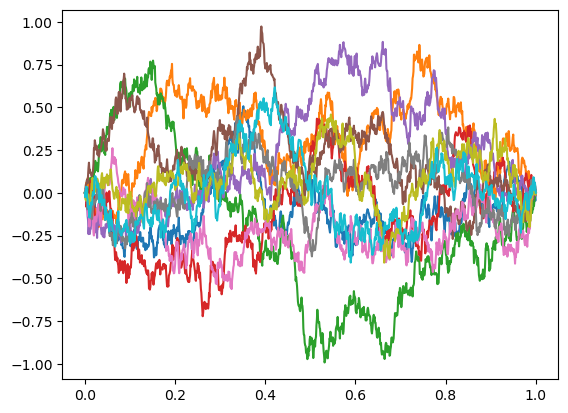

In [22]:
for i in range(iter):
    plt.plot(time_subintervals, brown_bridge_paths[i,:])

# The Milstein method

This is apparently "better" for approximating numberical solutions. For details, see https://en.wikipedia.org/wiki/Milstein_method

We use the equation for

$dY_t=\mu Ydt+\sigma YdW_t$ with $Y_0$=0.

We have the recursive defintion

$Y_{n+1}=Y_n+a(Y_n)\Delta t+b(Y_n)\Delta W_n+\frac{1}{2}b(Y_n)b'(Y_n)((\Delta W_n)^2-\Delta t)$, and $\Delta W_n = W_{\tau_{n+1}}-W_{\tau_n}$



In [48]:
# To make the presentation sligthly clearer, we draw a new pair of normally distributed variables.
mu = 2
sigma =1

# need to start at non-zero value.
x_0=1

T= 3
time_interval = [0,T]
subint_N = 60000
delta_T = (time_interval[1]-time_interval[0])/subint_N
time_subintervals = np.linspace(0, T, num=subint_N, endpoint=True)


normal_vect = rng.normal(0,1,subint_N)

y_path = np.zeros(subint_N)
y_path[0]=x_0

for i in range(1,subint_N):
    t = (i-1)*delta_T
    y = y_path[i-1]
    dW = normal_vect[i]*np.sqrt(delta_T)

    # sum up terms as in the Milstein method
    y_path[i]= y+mu*y*delta_T+sigma*y*dW+(sigma**2/2)*y*(dW**2-delta_T)
    

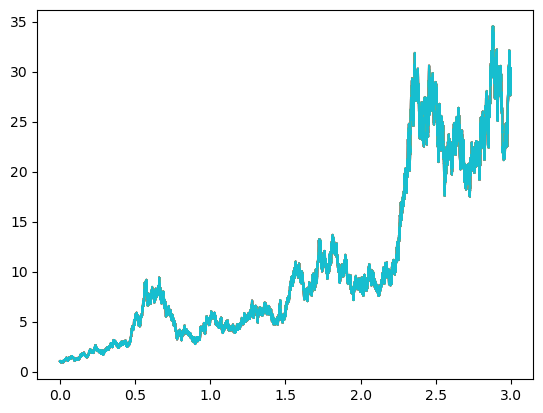

In [49]:
for i in range(iter):
    plt.plot(time_subintervals, y_path)